# 6.5 - CertCF atlas anchor selection diagnostics

This notebook compares **which anchors are selected** for the CertCF atlas while keeping the rest of the CertCF pipeline fixed.

It is meant to follow `6.4`, which studies `k_per_class` under the current atlas construction. Here, the focus is on a first anchor-selection experiment family:

- baseline: standard `k`-medoids selection
- variants: margin-stratified `k`-medoids with balanced and boundary-heavier allocations

The notebook is intentionally manual and self-contained so the selection logic, atlas build, coverage checks, and pilot-query diagnostics can all be inspected cell by cell.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

for candidate in [ROOT, ROOT / "src"]:
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from scipy.spatial.distance import cdist
from torch.utils.data import TensorDataset
from tqdm.auto import tqdm

from certcf.atlas import CertCFAtlas
from certcf.eps_strategies import NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks.registry import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

warnings.filterwarnings("ignore", message=".*Cluster .* is empty.*")


In [2]:
CONFIG_PATH = ROOT / "configs/benchmarks/benchmark_meeting_all_200q.yaml"

DATASETS = [
    "adult",
]
K_GRID = [100, 200, 300, 500]
ANCHOR_SELECTION_METHODS = [
    "kmedoids",
    "margin_stratified_kmedoids_balanced",
    "margin_stratified_kmedoids_boundary_heavy",
    "margin_stratified_kmedoids_boundary_very_heavy",
]
SELECTION_LABELS = {
    "kmedoids": "k-medoids",
    "margin_stratified_kmedoids_balanced": "Margin-stratified k-medoids (1:1:1)",
    "margin_stratified_kmedoids_boundary_heavy": "Margin-stratified k-medoids (3:2:1)",
    "margin_stratified_kmedoids_boundary_very_heavy": "Margin-stratified k-medoids (4:2:1)",
}
STRATUM_NAMES = ["boundary", "intermediate", "interior"]
SELECTION_STRATUM_RATIOS = {
    "margin_stratified_kmedoids_balanced": {
        "boundary": 1,
        "intermediate": 1,
        "interior": 1,
    },
    "margin_stratified_kmedoids_boundary_heavy": {
        "boundary": 3,
        "intermediate": 2,
        "interior": 1,
    },
    "margin_stratified_kmedoids_boundary_very_heavy": {
        "boundary": 4,
        "intermediate": 2,
        "interior": 1,
    },
}
LIRPA_METHOD = "backward"
CERTCF_PARAM_OVERRIDES = {
    "eps_alpha": 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
COVERAGE_BATCH_SIZE = 128
PILOT_N_QUERIES = 25
SEED = 42

print(CONFIG_PATH)
print(DATASETS)
print(K_GRID)
print(ANCHOR_SELECTION_METHODS)
print(SELECTION_STRATUM_RATIOS)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
[100, 200, 300, 500]
['kmedoids', 'margin_stratified_kmedoids_balanced', 'margin_stratified_kmedoids_boundary_heavy', 'margin_stratified_kmedoids_boundary_very_heavy']
{'margin_stratified_kmedoids_balanced': {'boundary': 1, 'intermediate': 1, 'interior': 1}, 'margin_stratified_kmedoids_boundary_heavy': {'boundary': 3, 'intermediate': 2, 'interior': 1}, 'margin_stratified_kmedoids_boundary_very_heavy': {'boundary': 4, 'intermediate': 2, 'interior': 1}}
backward
{'eps_alpha': 0.45}


In [3]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg["name"]: cfg for cfg in BENCHMARK_CFG["datasets"]}
SHARED_METHOD_CFGS = {cfg["name"]: cfg for cfg in BENCHMARK_CFG["methods"]}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f"Unknown datasets in DATASETS: {missing}")


def _norm_to_cdist_metric(norm_value):
    if norm_value == 1:
        return "cityblock"
    if norm_value == 2:
        return "euclidean"
    if norm_value == np.inf:
        return "chebyshev"
    raise ValueError(f"Unsupported norm for cdist conversion: {norm_value!r}")


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS["certcf"].get("params", {}))
    ds_overrides = DATASET_CFGS[dataset_name].get("method_overrides", {}).get("certcf", {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace("_", "-")


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _split_indices_into_strata(cls_idx, margins):
    cls_idx = np.asarray(cls_idx, dtype=np.int64)
    ordered = cls_idx[np.argsort(margins[cls_idx], kind="stable")]
    splits = np.array_split(ordered, len(STRATUM_NAMES))
    return {
        name: np.asarray(split, dtype=np.int64)
        for name, split in zip(STRATUM_NAMES, splits)
    }


def _selection_ratio_map(selection_method):
    try:
        raw_map = SELECTION_STRATUM_RATIOS[selection_method]
    except KeyError as exc:
        raise ValueError(f"No stratum ratio map configured for selection_method={selection_method!r}") from exc

    ratios = np.array([float(raw_map[name]) for name in STRATUM_NAMES], dtype=np.float64)
    if np.any(ratios < 0):
        raise ValueError("Selection stratum ratios must be non-negative.")
    total = float(ratios.sum())
    if total <= 0:
        raise ValueError("Selection stratum ratios must have positive total weight.")
    ratios /= total
    return {name: float(value) for name, value in zip(STRATUM_NAMES, ratios)}


def _allocate_stratum_counts(total_k, available_by_stratum, selection_method):
    total_k = int(total_k)
    if total_k <= 0:
        return {name: 0 for name in STRATUM_NAMES}

    ratio_map = _selection_ratio_map(selection_method)
    ratios = np.array([ratio_map[name] for name in STRATUM_NAMES], dtype=np.float64)
    available = np.array([int(available_by_stratum[name]) for name in STRATUM_NAMES], dtype=np.int64)

    raw = ratios * total_k
    counts = np.floor(raw).astype(np.int64)
    remainder = int(total_k - counts.sum())
    if remainder > 0:
        order = np.argsort(-(raw - counts))
        for idx in order[:remainder]:
            counts[idx] += 1

    counts = np.minimum(counts, available)
    remaining = int(min(total_k, int(available.sum())) - counts.sum())
    if remaining > 0:
        ratio_order = np.argsort(-ratios)
        while remaining > 0:
            moved = False
            for idx in ratio_order:
                if counts[idx] < available[idx]:
                    counts[idx] += 1
                    remaining -= 1
                    moved = True
                    if remaining == 0:
                        break
            if not moved:
                break

    return {name: int(counts[i]) for i, name in enumerate(STRATUM_NAMES)}


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get("dataset_params", {"data_dir": "data/"}))
    dataset_params["data_dir"] = str(_resolve_repo_path(dataset_params.get("data_dir", "data/")))
    dataset = REGISTRIES["dataset"].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg["model"]
    if model_cfg["name"] != "tabular_classifier_ckpt":
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get("params", {}))
    model_params["checkpoint"] = str(_resolve_repo_path(model_params["checkpoint"]))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params["checkpoint"],
        device=model_params.get("device", "cpu"),
        dataset_module=model_params.get("dataset_module", dataset_name),
        hidden_dims=list(model_params.get("hidden_dims", [32, 8])),
        dropout=float(model_params.get("dropout", 0.2)),
    )

    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get("norm", 2)).lower() in {"inf", "infinity"} else int(certcf_params.get("norm", 2))
    distance_norm_raw = certcf_params.get("distance_norm", cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {"inf", "infinity"} else int(distance_norm_raw)
    query_method = str(certcf_params.get("query_method", "sorted")).lower()
    default_lirpa_method = _resolve_lirpa_method(certcf_params.get("lirpa_method", "backward"))
    spec = getattr(dataset, "spec", None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    logits = _batched_logits(model, x_train)
    margins = _margin_scores(logits, y_train)

    return {
        "dataset_name": dataset_name,
        "dataset": dataset,
        "spec": spec,
        "x_train": np.asarray(x_train, dtype=np.float32),
        "y_train": np.asarray(y_train, dtype=np.int64),
        "x_test": np.asarray(x_test, dtype=np.float32),
        "y_test": np.asarray(y_test, dtype=np.int64),
        "model": model,
        "model_cfg": model_cfg,
        "certcf_params": certcf_params,
        "cert_norm": cert_norm,
        "distance_norm": distance_norm,
        "eps_alpha": float(certcf_params.get("eps_alpha", 0.25)),
        "query_method": query_method,
        "default_lirpa_method": default_lirpa_method,
        "ohe_slices": ohe_slices,
        "margin_scores": margins,
        "class_labels": [int(v) for v in np.unique(y_train)],
        "prototype_indices_cache": {},
        "atlas_cache": {},
        "class_strata_cache": {},
        "eval_indices_cache": {},
    }


def _get_class_strata(bundle, class_label):
    cache = bundle["class_strata_cache"]
    class_label = int(class_label)
    if class_label in cache:
        return cache[class_label]

    cls_idx = np.where(bundle["y_train"] == class_label)[0]
    strata = _split_indices_into_strata(cls_idx, bundle["margin_scores"])
    cache[class_label] = strata
    return strata


def _select_within_subset(x_subset, k):
    k = min(int(k), len(x_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(x_subset):
        return np.arange(len(x_subset), dtype=np.int64)
    return np.asarray(
        select_prototype_indices(
            x_subset,
            k=k,
            method="kmedoids",
            random_state=SEED,
        ),
        dtype=np.int64,
    )


def _get_prototype_indices(bundle, selection_method, k):
    cache = bundle["prototype_indices_cache"]
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    selected = []

    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        k_cls = min(int(k), len(cls_idx))

        if selection_method == "kmedoids":
            cls_local = _select_within_subset(x_train[cls_idx], k_cls)
            selected.append(cls_idx[cls_local])
            continue

        if selection_method in SELECTION_STRATUM_RATIOS:
            strata = _get_class_strata(bundle, int(class_label))
            available = {name: len(strata[name]) for name in STRATUM_NAMES}
            counts = _allocate_stratum_counts(k_cls, available, selection_method)
            chosen_parts = []
            for name in STRATUM_NAMES:
                stratum_idx = strata[name]
                n_pick = counts[name]
                if n_pick <= 0:
                    continue
                local = _select_within_subset(x_train[stratum_idx], n_pick)
                chosen_parts.append(stratum_idx[local])
            if chosen_parts:
                selected.append(np.concatenate(chosen_parts).astype(np.int64))
            else:
                selected.append(np.array([], dtype=np.int64))
            continue

        raise ValueError(f"Unknown selection_method: {selection_method!r}")

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[cache_key] = absolute_idx
    return absolute_idx


def _get_eval_indices(bundle, class_label, max_points=MAX_COVERAGE_POINTS_PER_CLASS):
    cache_key = (int(class_label), int(max_points) if max_points is not None else None)
    cache = bundle["eval_indices_cache"]
    if cache_key in cache:
        return cache[cache_key]

    cls_idx = np.where(bundle["y_train"] == int(class_label))[0]
    if max_points is not None and len(cls_idx) > max_points:
        rng = np.random.default_rng(SEED + 10_000 + int(class_label))
        eval_idx = np.sort(rng.choice(cls_idx, size=max_points, replace=False))
    else:
        eval_idx = cls_idx
    cache[cache_key] = eval_idx
    return eval_idx


def _build_certcf_atlas(bundle, selection_method, k):
    cache = bundle["atlas_cache"]
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    x_proto = bundle["x_train"][selected_idx]
    y_proto = bundle["y_train"][selected_idx]
    params = bundle["certcf_params"]

    atlas = CertCFAtlas(
        model=bundle["model"].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle["model"].device,
        cnn=False,
        norm=bundle["cert_norm"],
        distance_norm=bundle["distance_norm"],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=bundle["eps_alpha"]),
        batch_size=int(params.get("batch_size", 256)),
        ohe_slices=bundle["ohe_slices"],
        default_query_method=bundle["query_method"],
        solver_maxiter=int(params.get("solver_maxiter", 500)),
        lirpa_method=_resolve_lirpa_method(LIRPA_METHOD),
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return {
            "n_points": 0,
            "mean_distance": np.nan,
            "median_distance": np.nan,
            "p90_distance": np.nan,
            "p95_distance": np.nan,
            "max_distance": np.nan,
        }
    return {
        "n_points": int(len(values)),
        "mean_distance": float(np.mean(values)),
        "median_distance": float(np.median(values)),
        "p90_distance": float(np.quantile(values, 0.90)),
        "p95_distance": float(np.quantile(values, 0.95)),
        "max_distance": float(np.max(values)),
    }


def _selection_summary_rows(bundle, selection_method, k):
    y_train = bundle["y_train"]
    margins = bundle["margin_scores"]
    selected_idx = _get_prototype_indices(bundle, selection_method, k)

    rows = []
    total_counts = {name: 0 for name in STRATUM_NAMES}
    for class_label in bundle["class_labels"]:
        strata = _get_class_strata(bundle, int(class_label))
        class_selected = selected_idx[y_train[selected_idx] == int(class_label)]
        row = {
            "dataset": bundle["dataset_name"],
            "selection_method": selection_method,
            "selection_label": SELECTION_LABELS[selection_method],
            "class_label": int(class_label),
            "k_per_class": int(k),
            "n_selected": int(len(class_selected)),
            "selected_margin_mean": float(np.mean(margins[class_selected])) if len(class_selected) else np.nan,
            "selected_margin_median": float(np.median(margins[class_selected])) if len(class_selected) else np.nan,
        }
        for name in STRATUM_NAMES:
            count = int(np.isin(class_selected, strata[name]).sum())
            row[f"n_{name}"] = count
            total_counts[name] += count
        rows.append(row)

    rows.append({
        "dataset": bundle["dataset_name"],
        "selection_method": selection_method,
        "selection_label": SELECTION_LABELS[selection_method],
        "class_label": "overall",
        "k_per_class": int(k),
        "n_selected": int(len(selected_idx)),
        "selected_margin_mean": float(np.mean(margins[selected_idx])) if len(selected_idx) else np.nan,
        "selected_margin_median": float(np.median(margins[selected_idx])) if len(selected_idx) else np.nan,
        **{f"n_{name}": int(total_counts[name]) for name in STRATUM_NAMES},
    })
    return rows


def _prototype_distance_rows(bundle, selection_method, k):
    x_train = bundle["x_train"]
    y_train = bundle["y_train"]
    margins = bundle["margin_scores"]
    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    metric = _norm_to_cdist_metric(bundle["cert_norm"])

    rows = []
    overall_dists = []
    overall_low_margin_dists = []

    for class_label in bundle["class_labels"]:
        cls_idx = np.where(y_train == class_label)[0]
        proto_idx = selected_idx[y_train[selected_idx] == class_label]
        cls_dists = cdist(x_train[cls_idx], x_train[proto_idx], metric=metric).min(axis=1)
        overall_dists.append(cls_dists)

        class_threshold = np.quantile(margins[cls_idx], LOW_MARGIN_QUANTILE)
        low_margin_mask = margins[cls_idx] <= class_threshold
        low_margin_dists = cls_dists[low_margin_mask]
        overall_low_margin_dists.append(low_margin_dists)

        for subset_name, subset_dists in [("all", cls_dists), ("low_margin", low_margin_dists)]:
            row = {
                "dataset": bundle["dataset_name"],
                "selection_method": selection_method,
                "selection_label": SELECTION_LABELS[selection_method],
                "class_label": int(class_label),
                "k_per_class": int(k),
                "subset": subset_name,
                "n_prototypes_for_class": int(len(proto_idx)),
            }
            row.update(_summary_stats(subset_dists))
            rows.append(row)

    for subset_name, pieces in [("all", overall_dists), ("low_margin", overall_low_margin_dists)]:
        merged = np.concatenate([piece for piece in pieces if len(piece) > 0]) if pieces else np.array([], dtype=np.float64)
        row = {
            "dataset": bundle["dataset_name"],
            "selection_method": selection_method,
            "selection_label": SELECTION_LABELS[selection_method],
            "class_label": "overall",
            "k_per_class": int(k),
            "subset": subset_name,
            "n_prototypes_for_class": int(k),
        }
        row.update(_summary_stats(merged))
        rows.append(row)

    return rows


def _certified_cover_counts(atlas, target_class, x_eval, batch_size=COVERAGE_BATCH_SIZE, tol=1e-7):
    bd = atlas.bounds[int(target_class)]
    centers = np.asarray(bd["X"], dtype=np.float64)
    lA = np.asarray(bd["lA"], dtype=np.float64)
    lbias = np.asarray(bd["lbias"], dtype=np.float64)
    eps = np.asarray(bd["eps"], dtype=np.float64)
    metric = _norm_to_cdist_metric(atlas.norm)

    cover_counts = np.zeros(len(x_eval), dtype=np.int64)
    for start in range(0, len(x_eval), batch_size):
        xb = np.asarray(x_eval[start:start + batch_size], dtype=np.float64)
        halfspace = np.einsum("mjd,nd->mnj", lA, xb) + lbias[:, None, :]
        halfspace_ok = np.all(halfspace >= -tol, axis=2)
        ball_ok = cdist(centers, xb, metric=metric) <= eps[:, None] + tol
        cover_counts[start:start + batch_size] = np.sum(halfspace_ok & ball_ok, axis=0)
    return cover_counts


def _certified_membership_mask(atlas, target_class, x_eval, batch_size=COVERAGE_BATCH_SIZE, tol=1e-7):
    return _certified_cover_counts(
        atlas,
        target_class,
        x_eval,
        batch_size=batch_size,
        tol=tol,
    ) > 0


def _coverage_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle["x_train"]
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle["class_labels"]:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            "dataset": bundle["dataset_name"],
            "selection_method": selection_method,
            "selection_label": SELECTION_LABELS[selection_method],
            "class_label": int(class_label),
            "k_per_class": int(k),
            "n_eval": int(len(eval_idx)),
            "n_covered": int(covered.sum()),
            "coverage_rate": float(covered.mean()),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })

    rows.append({
        "dataset": bundle["dataset_name"],
        "selection_method": selection_method,
        "selection_label": SELECTION_LABELS[selection_method],
        "class_label": "overall",
        "k_per_class": int(k),
        "n_eval": int(total_eval),
        "n_covered": int(total_covered),
        "coverage_rate": float(total_covered / total_eval) if total_eval else np.nan,
        "build_time_s": float(build_time_s),
        "n_selected_total": int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle["x_train"]
    rows = []
    total_eval = 0
    total_cover_counts = []

    for class_label in bundle["class_labels"]:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_cover_counts.append(cover_counts)
        rows.append({
            "dataset": bundle["dataset_name"],
            "selection_method": selection_method,
            "selection_label": SELECTION_LABELS[selection_method],
            "class_label": int(class_label),
            "k_per_class": int(k),
            "n_eval": int(len(eval_idx)),
            "covered_rate": float(covered_mask.mean()),
            "multi_cover_rate": float(multi_mask.mean()),
            "mean_cover_count": float(np.mean(cover_counts)),
            "mean_cover_count_if_covered": float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            "mean_overlap_excess": float(np.mean(overlap_excess)),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        "dataset": bundle["dataset_name"],
        "selection_method": selection_method,
        "selection_label": SELECTION_LABELS[selection_method],
        "class_label": "overall",
        "k_per_class": int(k),
        "n_eval": int(total_eval),
        "covered_rate": float(covered_mask.mean()) if len(merged) else np.nan,
        "multi_cover_rate": float(multi_mask.mean()) if len(merged) else np.nan,
        "mean_cover_count": float(np.mean(merged)) if len(merged) else np.nan,
        "mean_cover_count_if_covered": float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        "mean_overlap_excess": float(np.mean(overlap_excess)) if len(merged) else np.nan,
        "build_time_s": float(build_time_s),
        "n_selected_total": int(len(selected_idx)),
    })
    return rows


def _pilot_query_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle["dataset_name"],
        x_test=bundle["x_test"],
        y_test=bundle["y_test"],
        model=bundle["model"],
        sampling_cfg={"n_queries": int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle["model"].predict_proba(bundle["x_test"][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    rows = []
    for query_idx, y_true_i, y_orig_i, target_class in zip(query_indices, y_true, y_orig, target_classes):
        result = atlas.find_counterfactual(
            x_query=bundle["x_test"][query_idx],
            target_class=int(target_class),
            method=bundle["query_method"],
        )
        rows.append({
            "dataset": bundle["dataset_name"],
            "selection_method": selection_method,
            "selection_label": SELECTION_LABELS[selection_method],
            "k_per_class": int(k),
            "query_idx": int(query_idx),
            "y_true": int(y_true_i),
            "y_orig": int(y_orig_i),
            "target_class": int(target_class),
            "success": bool(result.success),
            "distance": float(result.distance) if result.success else np.nan,
            "query_time_ms": float(result.profiling.get("total_time_ms", np.nan)),
            "build_time_s": float(build_time_s),
            "n_selected_total": int(len(selected_idx)),
        })
    return rows



In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    class_counts = pd.Series(bundle["y_train"]).value_counts().sort_index().to_dict()
    overview_rows.append({
        "dataset": dataset_name,
        "n_train": int(len(bundle["x_train"])),
        "n_test": int(len(bundle["x_test"])),
        "classes": class_counts,
        "cert_norm": bundle["cert_norm"],
        "distance_norm": bundle["distance_norm"],
        "eps_alpha": bundle["eps_alpha"],
        "query_method": bundle["query_method"],
        "lirpa_method": _resolve_lirpa_method(LIRPA_METHOD),
        "selection_methods": ", ".join(SELECTION_LABELS[name] for name in ANCHOR_SELECTION_METHODS),
    })

display(pd.DataFrame(overview_rows))


,dataset,n_train,n_test,classes,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method,selection_methods
0,adult,36178,4522,"{0: 27224, 1: 8954}",1,1,0.45,sorted,backward,"k-medoids, Margin-stratified k-medoids (1:1:1)..."


## 1. Anchor selection summary

Before building the atlas, this section checks which strata the selected anchors come from.

For each selection rule and `k_per_class`, we report:
- how many selected anchors fall in the boundary / intermediate / interior target-class strata
- the mean and median classifier margin of the selected anchors

This is a sanity check that the stratified selectors are actually changing the anchor distribution relative to the plain `k`-medoids baseline.


In [5]:
selection_rows = []
for dataset_name in tqdm(DATASETS, desc="Anchor selection summary"):
    bundle = bundles[dataset_name]
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            selection_rows.extend(_selection_summary_rows(bundle, selection_method, k))

selection_df = pd.DataFrame(selection_rows)
selection_overall = selection_df[selection_df["class_label"] == "overall"].copy()

display(selection_overall.sort_values(["dataset", "k_per_class", "selection_method"]))


Anchor selection summary:   0%|          | 0/1 [00:00<?, ?it/s]

,dataset,selection_method,selection_label,class_label,k_per_class,n_selected,selected_margin_mean,selected_margin_median,n_boundary,n_intermediate,n_interior
2,adult,kmedoids,k-medoids,overall,100,200,1.670025,1.046338,69,73,58
14,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,100,200,2.242157,1.111283,68,66,66
26,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,100,200,1.576388,0.840324,100,66,34
38,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,100,200,1.376098,0.752149,114,58,28
5,adult,kmedoids,k-medoids,overall,200,400,1.579059,1.052959,146,146,108
17,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,200,400,2.152675,1.116793,134,134,132
29,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,200,400,1.442957,0.838848,200,134,66
41,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,200,400,1.259880,0.792020,228,114,58
8,adult,kmedoids,k-medoids,overall,300,600,1.504499,1.021446,230,225,145
20,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,300,600,2.161091,1.115979,200,200,200


In [6]:
display(
    selection_overall[
        [
            "dataset",
            "selection_label",
            "k_per_class",
            "n_selected",
            "n_boundary",
            "n_intermediate",
            "n_interior",
            "selected_margin_mean",
            "selected_margin_median",
        ]
    ].sort_values(["dataset", "k_per_class", "selection_label"])
)


,dataset,selection_label,k_per_class,n_selected,n_boundary,n_intermediate,n_interior,selected_margin_mean,selected_margin_median
14,adult,Margin-stratified k-medoids (1:1:1),100,200,68,66,66,2.242157,1.111283
26,adult,Margin-stratified k-medoids (3:2:1),100,200,100,66,34,1.576388,0.840324
38,adult,Margin-stratified k-medoids (4:2:1),100,200,114,58,28,1.376098,0.752149
2,adult,k-medoids,100,200,69,73,58,1.670025,1.046338
17,adult,Margin-stratified k-medoids (1:1:1),200,400,134,134,132,2.152675,1.116793
29,adult,Margin-stratified k-medoids (3:2:1),200,400,200,134,66,1.442957,0.838848
41,adult,Margin-stratified k-medoids (4:2:1),200,400,228,114,58,1.259880,0.792020
5,adult,k-medoids,200,400,146,146,108,1.579059,1.052959
20,adult,Margin-stratified k-medoids (1:1:1),300,600,200,200,200,2.161091,1.115979
32,adult,Margin-stratified k-medoids (3:2:1),300,600,300,200,100,1.395862,0.826493


## 2. Prototype compression quality

This section asks whether the new anchor-selection rule changes how well the selected anchors represent the same-class training points in the CertCF certification norm.

We evaluate nearest-prototype distance on:
- `all`: every same-class training point
- `low_margin`: the bottom `LOW_MARGIN_QUANTILE` fraction of same-class points by classifier margin


In [7]:
compression_rows = []
for dataset_name in tqdm(DATASETS, desc="Compression diagnostics"):
    bundle = bundles[dataset_name]
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            compression_rows.extend(_prototype_distance_rows(bundle, selection_method, k))

compression_df = pd.DataFrame(compression_rows)
compression_overall = compression_df[compression_df["class_label"] == "overall"].copy()

display(
    compression_overall.sort_values(["dataset", "subset", "k_per_class", "selection_method"])[
        [
            "dataset",
            "selection_label",
            "k_per_class",
            "subset",
            "mean_distance",
            "p95_distance",
            "max_distance",
            "n_points",
        ]
    ]
)

Compression diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

,dataset,selection_label,k_per_class,subset,mean_distance,p95_distance,max_distance,n_points
4,adult,k-medoids,100,all,5.165995,10.369014,21.700456,36178
28,adult,Margin-stratified k-medoids (1:1:1),100,all,4.924758,10.200851,20.638066,36178
52,adult,Margin-stratified k-medoids (3:2:1),100,all,4.971158,10.212939,20.135237,36178
76,adult,Margin-stratified k-medoids (4:2:1),100,all,5.062031,10.320473,20.135237,36178
10,adult,k-medoids,200,all,4.643042,9.733247,20.135237,36178
34,adult,Margin-stratified k-medoids (1:1:1),200,all,4.466536,9.664127,19.878878,36178
58,adult,Margin-stratified k-medoids (3:2:1),200,all,4.580653,9.788019,20.189334,36178
82,adult,Margin-stratified k-medoids (4:2:1),200,all,4.603817,9.755715,19.950319,36178
16,adult,k-medoids,300,all,4.423526,9.450279,20.135237,36178
40,adult,Margin-stratified k-medoids (1:1:1),300,all,4.229960,9.265472,20.189334,36178


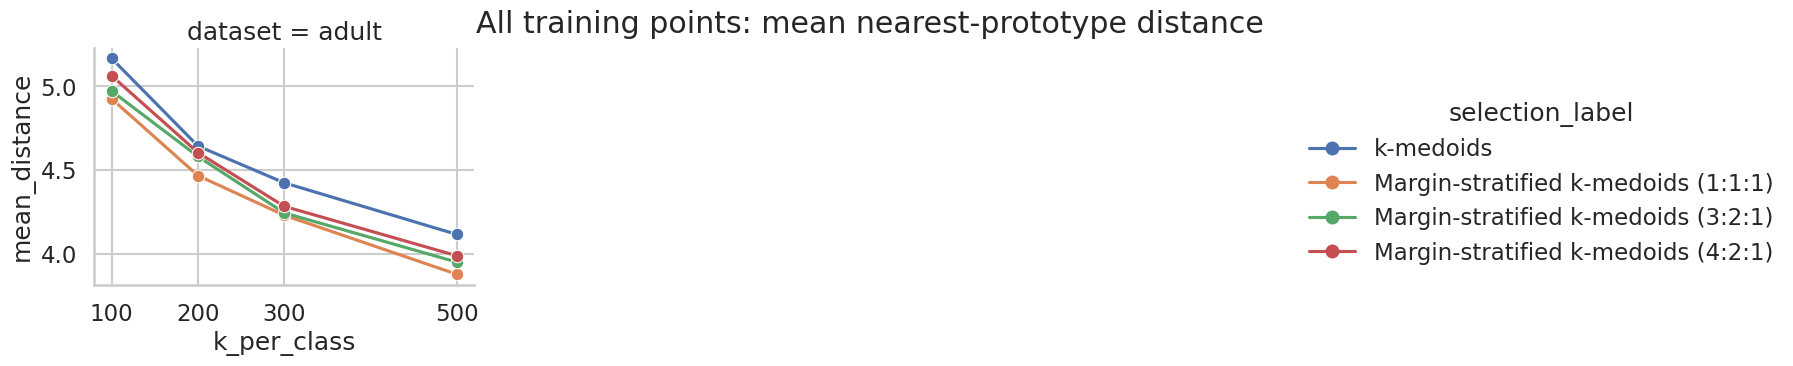

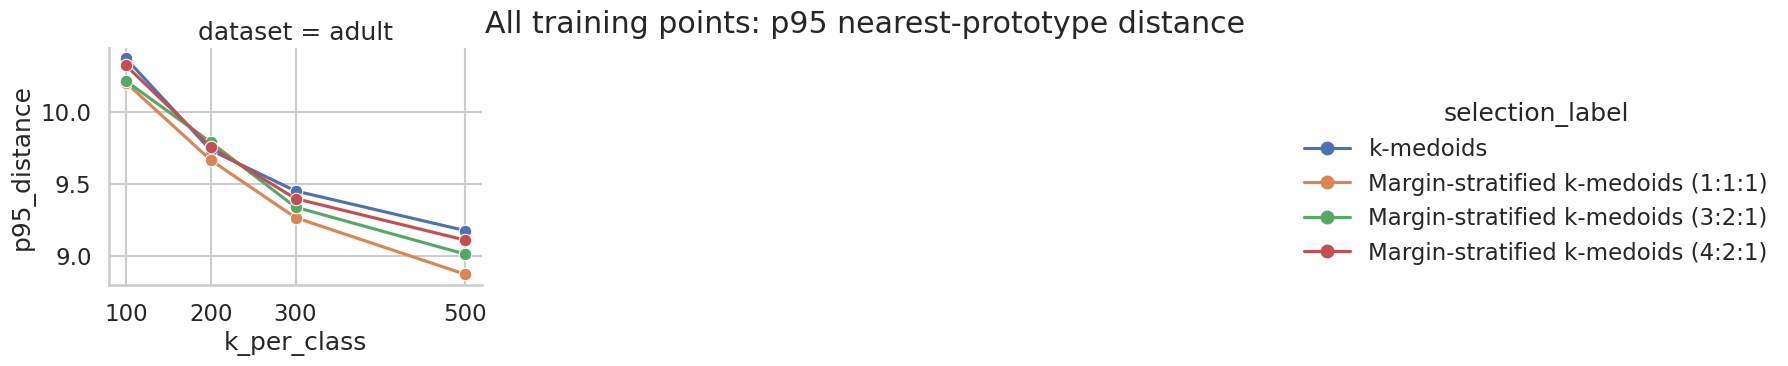

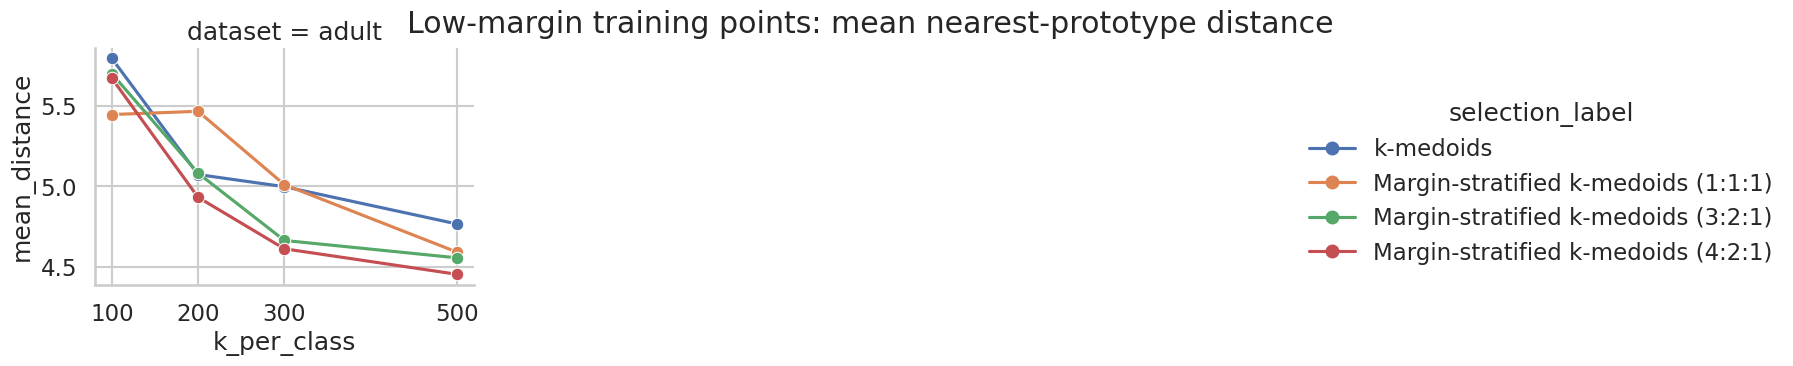

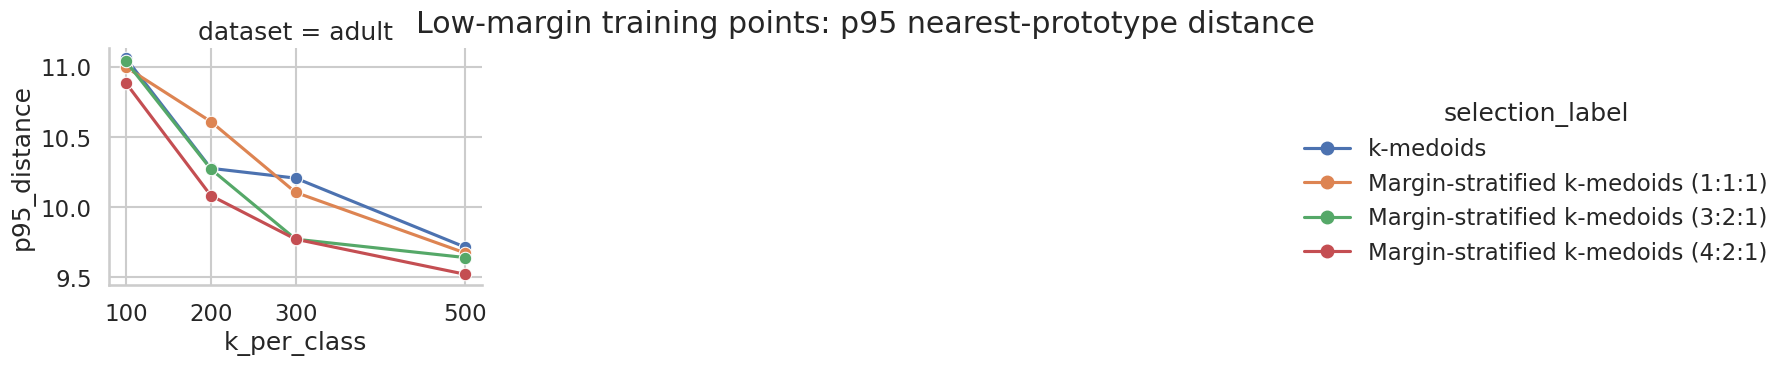

In [8]:
for subset_name, subset_label in [("all", "All training points"), ("low_margin", "Low-margin training points")]:
    subset_df = compression_overall[compression_overall["subset"] == subset_name].copy()
    for metric_name, title in [
        ("mean_distance", f"{subset_label}: mean nearest-prototype distance"),
        ("p95_distance", f"{subset_label}: p95 nearest-prototype distance"),
    ]:
        g = sns.relplot(
            data=subset_df,
            x="k_per_class",
            y=metric_name,
            hue="selection_label",
            col="dataset",
            col_wrap=3,
            kind="line",
            marker="o",
            facet_kws={"sharey": False},
            height=3.8,
            aspect=1.2,
        )
        g.fig.subplots_adjust(top=0.88)
        g.fig.suptitle(title)
        for ax in g.axes.flat:
            ax.set_xticks(K_GRID)
        plt.show()


## 3. Certified atlas coverage and overlap

Now we build the CertCF atlas for each anchor-selection rule and compare:

1. coverage: fraction of sampled same-class training points that lie in at least one certified same-class region
2. overlap: how often sampled same-class points are covered by multiple certified regions

This isolates the atlas-construction effect at fixed `k_per_class`.


In [9]:
coverage_rows = []
overlap_rows = []
for dataset_name in tqdm(DATASETS, desc="Coverage diagnostics"):
    bundle = bundles[dataset_name]
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            coverage_rows.extend(_coverage_rows(bundle, selection_method, k))
            overlap_rows.extend(_overlap_rows(bundle, selection_method, k))

coverage_df = pd.DataFrame(coverage_rows)
coverage_overall = coverage_df[coverage_df["class_label"] == "overall"].copy()
overlap_df = pd.DataFrame(overlap_rows)
overlap_overall = overlap_df[overlap_df["class_label"] == "overall"].copy()

display(coverage_overall.sort_values(["dataset", "k_per_class", "selection_method"]))
display(overlap_overall.sort_values(["dataset", "k_per_class", "selection_method"]))


Coverage diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:11<00:00,  5.91s/it]


,dataset,selection_method,selection_label,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
2,adult,kmedoids,k-medoids,overall,100,8000,241,0.030125,2.587414,200
14,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,100,8000,188,0.023500,2.354356,200
26,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,100,8000,146,0.018250,2.361018,200
38,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,100,8000,122,0.015250,2.426828,200
5,adult,kmedoids,k-medoids,overall,200,8000,332,0.041500,4.711179,400
17,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,200,8000,279,0.034875,4.733342,400
29,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,200,8000,207,0.025875,4.784676,400
41,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,200,8000,200,0.025000,4.694508,400
8,adult,kmedoids,k-medoids,overall,300,8000,386,0.048250,7.063426,600
20,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,300,8000,331,0.041375,7.018694,600


,dataset,selection_method,selection_label,class_label,k_per_class,n_eval,covered_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
2,adult,kmedoids,k-medoids,overall,100,8000,0.030125,0.003875,0.038000,1.261411,0.007875,2.587414,200
14,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,100,8000,0.023500,0.000250,0.023750,1.010638,0.000250,2.354356,200
26,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,100,8000,0.018250,0.000375,0.018625,1.020548,0.000375,2.361018,200
38,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,100,8000,0.015250,0.000625,0.016000,1.049180,0.000750,2.426828,200
5,adult,kmedoids,k-medoids,overall,200,8000,0.041500,0.003500,0.051875,1.250000,0.010375,4.711179,400
17,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,200,8000,0.034875,0.002250,0.038250,1.096774,0.003375,4.733342,400
29,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),overall,200,8000,0.025875,0.000625,0.026625,1.028986,0.000750,4.784676,400
41,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),overall,200,8000,0.025000,0.001000,0.026125,1.045000,0.001125,4.694508,400
8,adult,kmedoids,k-medoids,overall,300,8000,0.048250,0.006750,0.061875,1.282383,0.013625,7.063426,600
20,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),overall,300,8000,0.041375,0.004125,0.046500,1.123867,0.005125,7.018694,600


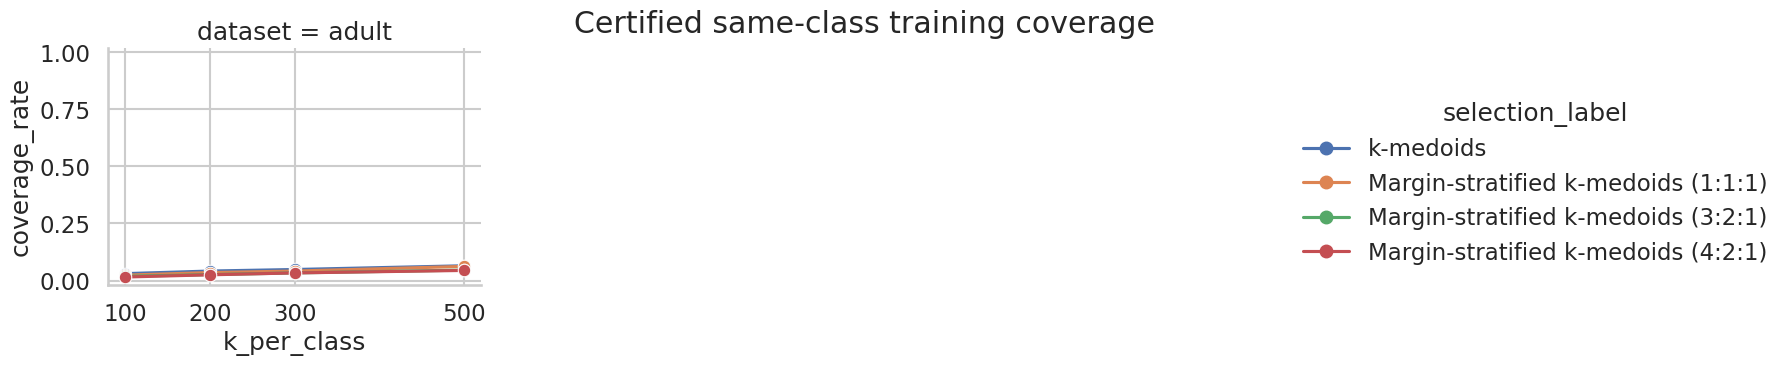

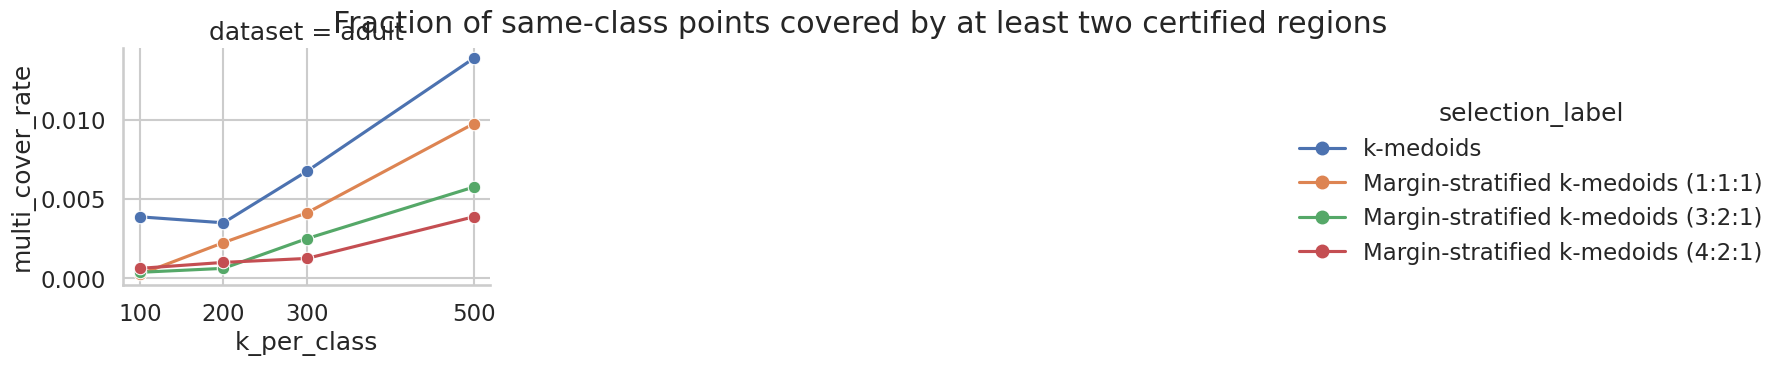

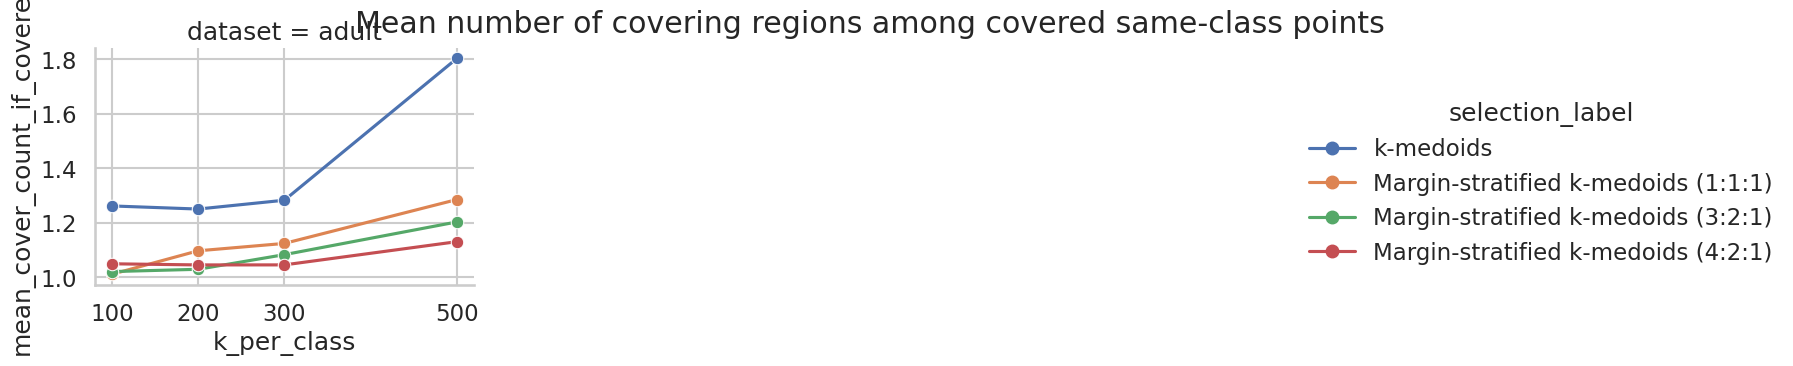

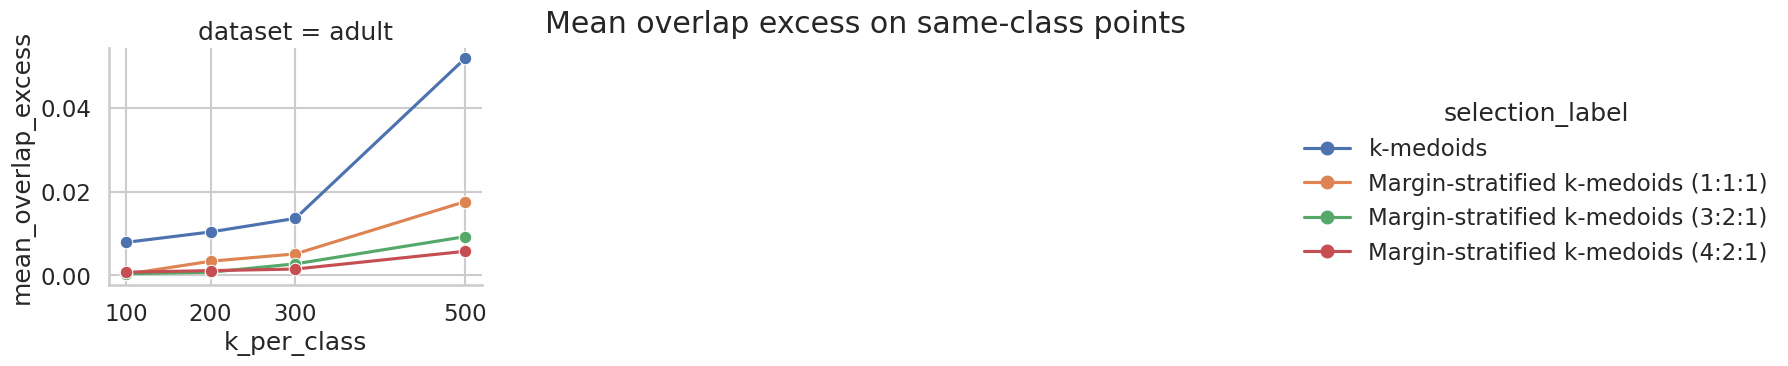

In [10]:
for metric_name, title, ylim in [
    ("coverage_rate", "Certified same-class training coverage", (-0.02, 1.02)),
    ("multi_cover_rate", "Fraction of same-class points covered by at least two certified regions", None),
    ("mean_cover_count_if_covered", "Mean number of covering regions among covered same-class points", None),
    ("mean_overlap_excess", "Mean overlap excess on same-class points", None),
]:
    plot_df = coverage_overall if metric_name == "coverage_rate" else overlap_overall
    g = sns.relplot(
        data=plot_df,
        x="k_per_class",
        y=metric_name,
        hue="selection_label",
        col="dataset",
        col_wrap=3,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.8,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(title)
    for ax in g.axes.flat:
        ax.set_xticks(K_GRID)
        if ylim is not None:
            ax.set_ylim(*ylim)
    plt.show()


## 4. Pilot query diagnostics

Finally, we run a small fixed pilot query set and compare the end-to-end CertCF behavior under the different anchor-selection rules.

Measured quantities:
- success rate
- mean / median counterfactual distance
- mean / median query time
- atlas build time


In [11]:
pilot_rows = []
for dataset_name in tqdm(DATASETS, desc="Pilot query diagnostics"):
    bundle = bundles[dataset_name]
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            pilot_rows.extend(_pilot_query_rows(bundle, selection_method, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_summary = (
    pilot_df.groupby(["dataset", "selection_method", "selection_label", "k_per_class"], as_index=False)
    .agg(
        n_queries=("query_idx", "count"),
        success_rate=("success", "mean"),
        mean_distance=("distance", "mean"),
        median_distance=("distance", "median"),
        mean_query_time_ms=("query_time_ms", "mean"),
        median_query_time_ms=("query_time_ms", "median"),
        build_time_s=("build_time_s", "first"),
    )
)

display(pilot_summary.sort_values(["dataset", "k_per_class", "selection_method"]))


Pilot query diagnostics:   0%|          | 0/1 [00:00<?, ?it/s]

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,dataset,selection_method,selection_label,k_per_class,n_queries,success_rate,mean_distance,median_distance,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,kmedoids,k-medoids,100,25,1.0,10.133099,11.148364,1540.089102,949.827383,2.587414
4,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),100,25,1.0,9.649500,10.424808,1695.317981,1703.550993,2.354356
8,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),100,25,1.0,9.681135,10.424808,3073.033861,3325.476306,2.361018
12,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),100,25,1.0,9.880109,10.669424,2320.346171,2399.240611,2.426828
1,adult,kmedoids,k-medoids,200,25,1.0,8.929708,9.407626,2082.472063,1868.461093,4.711179
5,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),200,25,1.0,8.618581,8.719121,2917.467814,2407.570995,4.733342
9,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),200,25,1.0,8.861920,9.094770,2986.218003,2200.660053,4.784676
13,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),200,25,1.0,9.414177,10.466208,4671.600975,4099.243755,4.694508
2,adult,kmedoids,k-medoids,300,25,1.0,8.725187,9.046485,4143.622862,4014.422077,7.063426
6,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),300,25,1.0,8.790314,9.243783,4075.238349,4366.517430,7.018694


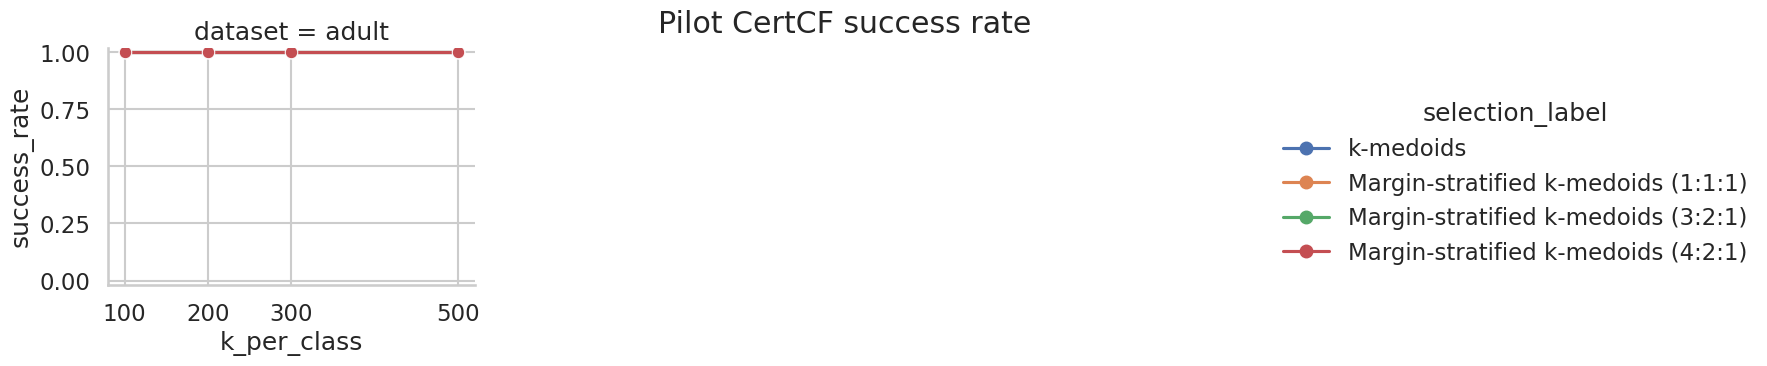

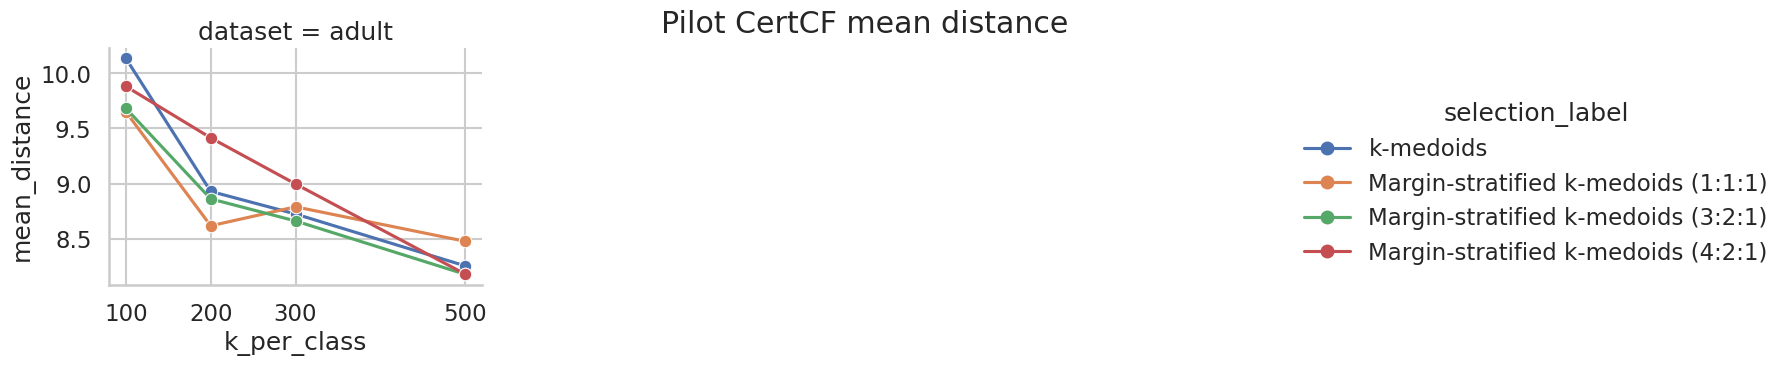

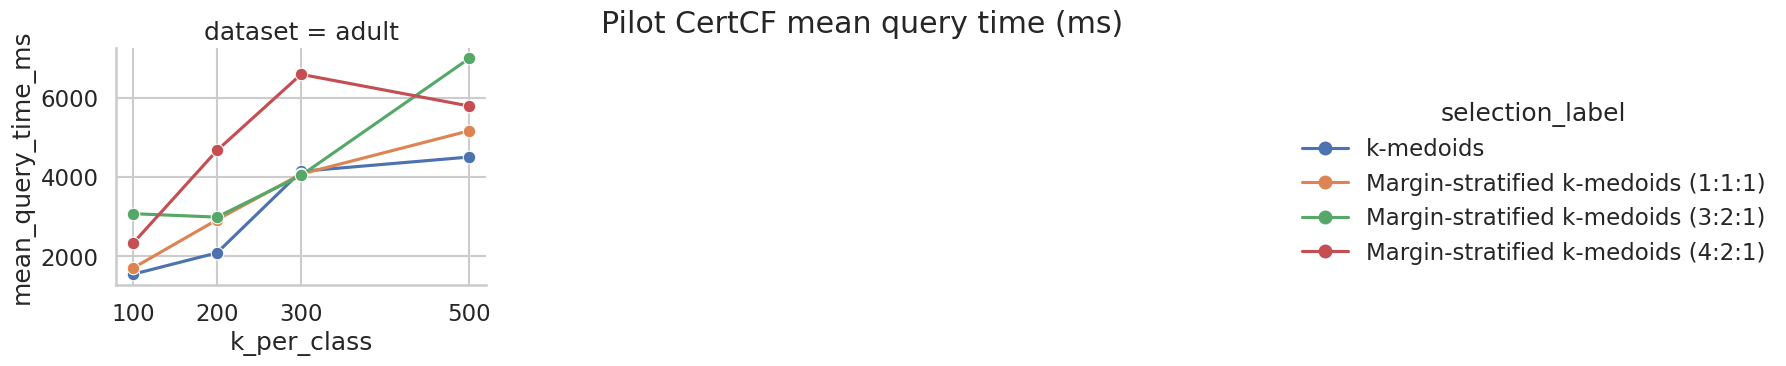

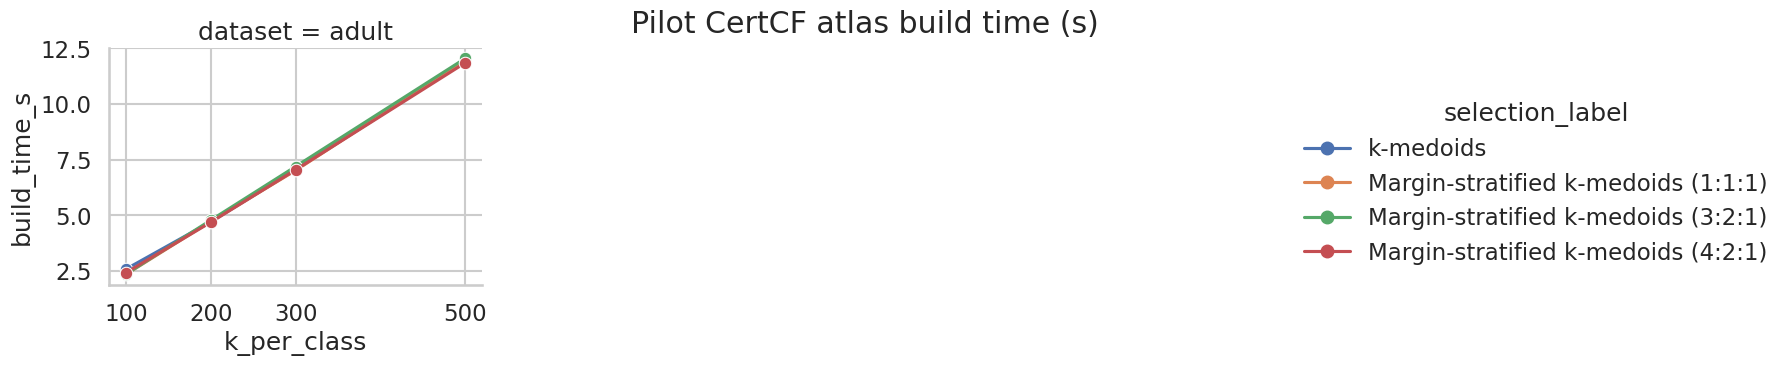

In [12]:
for metric_name, title, ylim in [
    ("success_rate", "Pilot CertCF success rate", (-0.02, 1.02)),
    ("mean_distance", "Pilot CertCF mean distance", None),
    ("mean_query_time_ms", "Pilot CertCF mean query time (ms)", None),
    ("build_time_s", "Pilot CertCF atlas build time (s)", None),
]:
    g = sns.relplot(
        data=pilot_summary,
        x="k_per_class",
        y=metric_name,
        hue="selection_label",
        col="dataset",
        col_wrap=3,
        kind="line",
        marker="o",
        facet_kws={"sharey": False},
        height=3.8,
        aspect=1.2,
    )
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(title)
    for ax in g.axes.flat:
        ax.set_xticks(K_GRID)
        if ylim is not None:
            ax.set_ylim(*ylim)
    plt.show()


## 5. Side-by-side comparison tables

This section merges the main diagnostics into pairwise comparisons between the baseline `k`-medoids atlas and each margin-stratified variant at the same `k_per_class`.


In [13]:
comparison_df = (
    coverage_overall[["dataset", "selection_method", "selection_label", "k_per_class", "coverage_rate"]]
    .merge(
        overlap_overall[["dataset", "selection_method", "selection_label", "k_per_class", "multi_cover_rate", "mean_overlap_excess"]],
        on=["dataset", "selection_method", "selection_label", "k_per_class"],
        how="inner",
    )
    .merge(
        compression_overall[compression_overall["subset"] == "low_margin"][
            ["dataset", "selection_method", "selection_label", "k_per_class", "p95_distance", "mean_distance"]
        ].rename(columns={
            "mean_distance": "low_margin_mean_nearest_proto_distance",
            "p95_distance": "low_margin_p95_nearest_proto_distance",
        }),
        on=["dataset", "selection_method", "selection_label", "k_per_class"],
        how="inner",
    )
    .merge(
        pilot_summary[[
            "dataset",
            "selection_method",
            "selection_label",
            "k_per_class",
            "success_rate",
            "mean_distance",
            "median_distance",
            "mean_query_time_ms",
            "median_query_time_ms",
            "build_time_s",
        ]].rename(columns={
            "mean_distance": "pilot_mean_distance",
            "median_distance": "pilot_median_distance",
        }),
        on=["dataset", "selection_method", "selection_label", "k_per_class"],
        how="inner",
    )
)

display(comparison_df.sort_values(["dataset", "k_per_class", "selection_label"]))

baseline = comparison_df[comparison_df["selection_method"] == "kmedoids"].copy()
variant_rows = comparison_df[comparison_df["selection_method"] != "kmedoids"].copy()
side_by_side = baseline.merge(
    variant_rows,
    on=["dataset", "k_per_class"],
    suffixes=("_baseline", "_variant"),
)
for metric in [
    "coverage_rate",
    "multi_cover_rate",
    "mean_overlap_excess",
    "low_margin_mean_nearest_proto_distance",
    "low_margin_p95_nearest_proto_distance",
    "success_rate",
    "pilot_mean_distance",
    "pilot_median_distance",
    "mean_query_time_ms",
    "median_query_time_ms",
    "build_time_s",
]:
    side_by_side[f"delta_{metric}"] = side_by_side[f"{metric}_variant"] - side_by_side[f"{metric}_baseline"]

display(side_by_side.sort_values(["dataset", "k_per_class", "selection_label_variant"]))


,dataset,selection_method,selection_label,k_per_class,coverage_rate,multi_cover_rate,mean_overlap_excess,low_margin_p95_nearest_proto_distance,low_margin_mean_nearest_proto_distance,success_rate,pilot_mean_distance,pilot_median_distance,mean_query_time_ms,median_query_time_ms,build_time_s
4,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),100,0.023500,0.000250,0.000250,10.998537,5.446323,1.0,9.649500,10.424808,1695.317981,1703.550993,2.354356
8,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),100,0.018250,0.000375,0.000375,11.039473,5.700537,1.0,9.681135,10.424808,3073.033861,3325.476306,2.361018
12,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),100,0.015250,0.000625,0.000750,10.885419,5.671470,1.0,9.880109,10.669424,2320.346171,2399.240611,2.426828
0,adult,kmedoids,k-medoids,100,0.030125,0.003875,0.007875,11.061469,5.794790,1.0,10.133099,11.148364,1540.089102,949.827383,2.587414
5,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),200,0.034875,0.002250,0.003375,10.610982,5.466393,1.0,8.618581,8.719121,2917.467814,2407.570995,4.733342
9,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),200,0.025875,0.000625,0.000750,10.272281,5.082481,1.0,8.861920,9.094770,2986.218003,2200.660053,4.784676
13,adult,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),200,0.025000,0.001000,0.001125,10.083150,4.932585,1.0,9.414177,10.466208,4671.600975,4099.243755,4.694508
1,adult,kmedoids,k-medoids,200,0.041500,0.003500,0.010375,10.277725,5.073947,1.0,8.929708,9.407626,2082.472063,1868.461093,4.711179
6,adult,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),300,0.041375,0.004125,0.005125,10.105869,5.011419,1.0,8.790314,9.243783,4075.238349,4366.517430,7.018694
10,adult,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),300,0.033250,0.002500,0.002750,9.772423,4.664945,1.0,8.662263,8.881001,4040.251458,4029.032690,7.195260


,dataset,selection_method_baseline,selection_label_baseline,k_per_class,coverage_rate_baseline,multi_cover_rate_baseline,mean_overlap_excess_baseline,low_margin_p95_nearest_proto_distance_baseline,low_margin_mean_nearest_proto_distance_baseline,success_rate_baseline,pilot_mean_distance_baseline,pilot_median_distance_baseline,mean_query_time_ms_baseline,median_query_time_ms_baseline,build_time_s_baseline,selection_method_variant,selection_label_variant,coverage_rate_variant,multi_cover_rate_variant,mean_overlap_excess_variant,low_margin_p95_nearest_proto_distance_variant,low_margin_mean_nearest_proto_distance_variant,success_rate_variant,pilot_mean_distance_variant,pilot_median_distance_variant,mean_query_time_ms_variant,median_query_time_ms_variant,build_time_s_variant,delta_coverage_rate,delta_multi_cover_rate,delta_mean_overlap_excess,delta_low_margin_mean_nearest_proto_distance,delta_low_margin_p95_nearest_proto_distance,delta_success_rate,delta_pilot_mean_distance,delta_pilot_median_distance,delta_mean_query_time_ms,delta_median_query_time_ms,delta_build_time_s
0,adult,kmedoids,k-medoids,100,0.030125,0.003875,0.007875,11.061469,5.794790,1.0,10.133099,11.148364,1540.089102,949.827383,2.587414,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),0.023500,0.000250,0.000250,10.998537,5.446323,1.0,9.649500,10.424808,1695.317981,1703.550993,2.354356,-0.006625,-0.003625,-0.007625,-0.348467,-0.062932,0.0,-0.483600,-0.723556,155.228879,753.723610,-0.233059
1,adult,kmedoids,k-medoids,100,0.030125,0.003875,0.007875,11.061469,5.794790,1.0,10.133099,11.148364,1540.089102,949.827383,2.587414,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),0.018250,0.000375,0.000375,11.039473,5.700537,1.0,9.681135,10.424808,3073.033861,3325.476306,2.361018,-0.011875,-0.003500,-0.007500,-0.094253,-0.021997,0.0,-0.451964,-0.723556,1532.944759,2375.648923,-0.226396
2,adult,kmedoids,k-medoids,100,0.030125,0.003875,0.007875,11.061469,5.794790,1.0,10.133099,11.148364,1540.089102,949.827383,2.587414,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),0.015250,0.000625,0.000750,10.885419,5.671470,1.0,9.880109,10.669424,2320.346171,2399.240611,2.426828,-0.014875,-0.003250,-0.007125,-0.123320,-0.176050,0.0,-0.252990,-0.478940,780.257069,1449.413228,-0.160586
3,adult,kmedoids,k-medoids,200,0.041500,0.003500,0.010375,10.277725,5.073947,1.0,8.929708,9.407626,2082.472063,1868.461093,4.711179,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),0.034875,0.002250,0.003375,10.610982,5.466393,1.0,8.618581,8.719121,2917.467814,2407.570995,4.733342,-0.006625,-0.001250,-0.007000,0.392446,0.333257,0.0,-0.311127,-0.688505,834.995751,539.109902,0.022163
4,adult,kmedoids,k-medoids,200,0.041500,0.003500,0.010375,10.277725,5.073947,1.0,8.929708,9.407626,2082.472063,1868.461093,4.711179,margin_stratified_kmedoids_boundary_heavy,Margin-stratified k-medoids (3:2:1),0.025875,0.000625,0.000750,10.272281,5.082481,1.0,8.861920,9.094770,2986.218003,2200.660053,4.784676,-0.015625,-0.002875,-0.009625,0.008535,-0.005444,0.0,-0.067788,-0.312856,903.745939,332.198960,0.073497
5,adult,kmedoids,k-medoids,200,0.041500,0.003500,0.010375,10.277725,5.073947,1.0,8.929708,9.407626,2082.472063,1868.461093,4.711179,margin_stratified_kmedoids_boundary_very_heavy,Margin-stratified k-medoids (4:2:1),0.025000,0.001000,0.001125,10.083150,4.932585,1.0,9.414177,10.466208,4671.600975,4099.243755,4.694508,-0.016500,-0.002500,-0.009250,-0.141361,-0.194575,0.0,0.484469,1.058582,2589.128912,2230.782662,-0.016671
6,adult,kmedoids,k-medoids,300,0.048250,0.006750,0.013625,10.207710,4.998638,1.0,8.725187,9.046485,4143.622862,4014.422077,7.063426,margin_stratified_kmedoids_balanced,Margin-stratified k-medoids (1:1:1),0.041375,0.004125,0.005125,10.105869,5.011419,1.0,8.790314,9.243783,4075.238349,4366.517430,7.018694,-0.006875,-0.002625,-0.008500,0.012782,-0.101841,0.0,0.065126,0.197299,-68.384512,352.095353,-0.044732
7,adu